In [80]:
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.preprocessing import StandardScaler

print(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

cuda



#### Load dataset

In [81]:
csv_file = "black_oil_final_dataset.csv"

df = pd.read_csv(csv_file)
print(df.shape)
df.head()


(55000, 49)


,sim_id,Nx,Ny,Lx,Ly,h,total_years,dt_days,rw,skin,...,final_cum_water_inj_m3,final_recovery_factor,final_p_min_MPa,final_p_max_MPa,final_p_mean_MPa,final_Sw_min,final_Sw_max,final_Sw_mean,final_Sw_producer,OOIP_surface_m3
0,0,15,15,500.0,500.0,20.0,20.0,10.0,0.1,0.0,...,3.145828e+05,0.324238,17.991275,28.555147,25.514558,0.329588,0.747258,0.462766,0.381910,561445.772763
1,1,15,15,500.0,500.0,20.0,20.0,10.0,0.1,0.0,...,5.516713e+05,0.532796,16.025292,23.338072,20.796022,0.343523,0.786663,0.560538,0.463907,776170.078117
2,2,15,15,500.0,500.0,20.0,20.0,10.0,0.1,0.0,...,5.794511e+05,0.464993,13.909596,25.279079,21.181899,0.408326,0.767124,0.556214,0.479929,725726.585541
3,3,15,15,500.0,500.0,20.0,20.0,10.0,0.1,0.0,...,7.267986e+05,0.546319,16.647350,27.642617,23.936056,0.454174,0.765581,0.576969,0.516510,641998.277787
4,4,15,15,500.0,500.0,20.0,20.0,10.0,0.1,0.0,...,1.270855e+06,0.910734,17.267873,24.512900,21.515695,0.626931,0.798993,0.726553,0.683905,624808.888685


In [82]:
df = df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
print('cleaned:', df.shape)


cleaned: (55000, 49)



#### X/Y df's

In [83]:

feature_cols = [
    "Lx","Ly","h",
    'phi','k_mD','p_init_MPa','Sw_init',
    'p_inj_bhp_MPa','p_prod_bhp_MPa',
    'p_ref_MPa','Bw_ref','Bo_ref','cw_1_per_Pa','co_1_per_Pa',
    'mu_w_cP','mu_o_cP','rho_w_sc','rho_o_sc',
    'Swc','Sor','krw0','kro0','nw_exp','no_exp',
    'OOIP_surface_m3',
]

target_cols = [
    'final_cum_oil_prod_m3',
    'final_cum_water_prod_m3',
    'final_cum_water_inj_m3',
    'final_recovery_factor'
]
full_cols = feature_cols + target_cols

X = df[feature_cols].astype(np.float32).values
Y = df[target_cols].astype(np.float32).values

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_scaled = x_scaler.fit_transform(X).astype(np.float32)
Y_scaled = y_scaler.fit_transform(Y).astype(np.float32)

print('X:', X_scaled.shape, 'Y:', Y_scaled.shape)


X: (55000, 25) Y: (55000, 4)



#### dataset class

In [84]:

@dataclass
class GridConfig:
    model_Nx: int = 32
    model_Ny: int = 32

grid_cfg = GridConfig(model_Nx=32, model_Ny=32)


class BlackOilScalarDataset(Dataset):
    def __init__(self, df, X_scaled, Y_scaled, feature_cols, target_cols, grid_cfg):
        self.df = df.reset_index(drop=True)
        self.X_scaled = torch.tensor(X_scaled, dtype=torch.float32)
        self.Y_scaled = torch.tensor(Y_scaled, dtype=torch.float32)
        self.feature_cols = list(feature_cols)
        self.target_cols = list(target_cols)
        self.grid_cfg = grid_cfg

        yy, xx = torch.meshgrid(
            torch.linspace(0, 1, grid_cfg.model_Ny),
            torch.linspace(0, 1, grid_cfg.model_Nx),
            indexing='ij',
        )
        self.xx = xx.float()
        self.yy = yy.float()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        xvec = self.X_scaled[idx]
        yvec = self.Y_scaled[idx]

        H, W = self.grid_cfg.model_Ny, self.grid_cfg.model_Nx
        param_maps = xvec[:, None, None].expand(-1, H, W)
        inp = torch.cat([
            self.xx[None, :, :],
            self.yy[None, :, :],
            param_maps
        ], dim=0)

        raw = {c: float(self.df.loc[idx, c]) for c in self.df.columns if c in full_cols}
        return inp, xvec, yvec, raw


dataset = BlackOilScalarDataset(df, X_scaled, Y_scaled, feature_cols, target_cols, grid_cfg)

n_train = int(0.8 * len(dataset))
n_val = len(dataset) - n_train

generator = torch.Generator()#.manual_seed(42)
train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=generator)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

sample = dataset[0]
sample[0].shape, sample[1].shape, sample[2].shape


(torch.Size([27, 32, 32]), torch.Size([25]), torch.Size([4]))

#### U-Net

In [85]:

class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, 3, padding=1),
            nn.GroupNorm(8 if c_out >= 8 else 1, c_out),
            nn.SiLU(),
            nn.Conv2d(c_out, c_out, 3, padding=1),
            nn.GroupNorm(8 if c_out >= 8 else 1, c_out),
            nn.SiLU(),
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_channels, n_scalar_targets, base=48):
        super().__init__()

        self.enc1 = ConvBlock(in_channels, base)
        self.enc2 = ConvBlock(base, base * 2)
        self.enc3 = ConvBlock(base * 2, base * 4)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(base * 4, base * 8)

        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = ConvBlock(base * 8, base * 4)

        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = ConvBlock(base * 4, base * 2)

        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = ConvBlock(base * 2, base)

        self.field_head = nn.Conv2d(base, 2, 1)  # 0 - p 1 - Sw

        self.scalar_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(base * 8, base * 4),
            nn.SiLU(),
            nn.Linear(base * 4, n_scalar_targets),
        )

    def forward(self, x):
        e1 = self.enc1(x)                  # 32x32
        e2 = self.enc2(self.pool(e1))      # 16x16
        e3 = self.enc3(self.pool(e2))      # 8x8
        b = self.bottleneck(self.pool(e3)) # 4x4

        u3 = self.up3(b)
        d3 = self.dec3(torch.cat([u3, e3], dim=1))
        u2 = self.up2(d3)
        d2 = self.dec2(torch.cat([u2, e2], dim=1))
        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        fields_raw = self.field_head(d1)
        p = fields_raw[:, 0:1]
        Sw = torch.sigmoid(fields_raw[:, 1:2])

        scalar_scaled = self.scalar_head(b)

        return p, Sw, scalar_scaled

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
in_channels = 2 + len(feature_cols)
model = UNet(in_channels=in_channels, n_scalar_targets=len(target_cols), base=32).to(device)

sum(p.numel() for p in model.parameters())


1968774

#### differentiable postprocessing

In [86]:

target_index = {c: i for i, c in enumerate(target_cols)}
feature_index = {c: i for i, c in enumerate(feature_cols)}

def unscale_y(y_scaled_t):
    mean = torch.tensor(y_scaler.mean_, dtype=torch.float32, device=y_scaled_t.device)
    scale = torch.tensor(y_scaler.scale_, dtype=torch.float32, device=y_scaled_t.device)
    return y_scaled_t * scale + mean

def unscale_x(x_scaled_t):
    mean = torch.tensor(x_scaler.mean_, dtype=torch.float32, device=x_scaled_t.device)
    scale = torch.tensor(x_scaler.scale_, dtype=torch.float32, device=x_scaled_t.device)
    return x_scaled_t * scale + mean

def recovery_factor_from_fields(p_MPa, Sw, x_raw):
    B, _, H, W = Sw.shape

    phi = x_raw[:, feature_index["phi"]]
    Lx = x_raw[:, feature_index["Lx"]]
    Ly = x_raw[:, feature_index["Ly"]]
    h = x_raw[:, feature_index["h"]]
    Bo_ref = x_raw[:, feature_index["Bo_ref"]]
    co = x_raw[:, feature_index["co_1_per_Pa"]]
    p_ref_MPa = x_raw[:, feature_index["p_ref_MPa"]]
    OOIP = x_raw[:, feature_index["OOIP_surface_m3"]].clamp_min(1e-6)

    p_Pa = p_MPa[:, 0] * 1e6
    p_ref_Pa = p_ref_MPa[:, None, None] * 1e6
    Bo = Bo_ref[:, None, None] / (1.0 + co[:, None, None] * (p_Pa - p_ref_Pa))
    Bo = Bo.clamp_min(0.1)

    cell_volume = (Lx * Ly * h / (H * W))[:, None, None]
    OIP_surface = torch.sum(phi[:, None, None] * cell_volume * (1.0 - Sw[:, 0]) / Bo, dim=(1,2))
    RF = (OOIP - OIP_surface) / OOIP
    return RF.clamp(-1.0, 2.0)

def bhp_boundary_loss(p_MPa, x_raw):
    p_inj = x_raw[:, feature_index["p_inj_bhp_MPa"]]
    p_prod = x_raw[:, feature_index["p_prod_bhp_MPa"]]

    p_inj_pred = p_MPa[:, 0, 0, 0]
    p_prod_pred = p_MPa[:, 0, -1, -1]

    return F.mse_loss(p_inj_pred, p_inj) + F.mse_loss(p_prod_pred, p_prod)

def smoothness_loss(field):
    dx = field[:, :, :, 1:] - field[:, :, :, :-1]
    dy = field[:, :, 1:, :] - field[:, :, :-1, :]
    return (dx ** 2).mean() + (dy ** 2).mean()

def rf_consistency_loss(p_MPa, Sw, y_true_scaled, x_raw):
    y_true = unscale_y(y_true_scaled)
    RF_pred = recovery_factor_from_fields(p_MPa, Sw, x_raw)
    RF_true = y_true[:, target_index["final_recovery_factor"]]
    return F.mse_loss(RF_pred, RF_true), RF_pred



#### Training part

In [87]:

def train_one_epoch(model, loader, optimizer, lambdas):
    model.train()
    total = 0.0

    for inp, x_scaled, y_scaled, _ in tqdm(loader, leave=False):
        inp = inp.to(device)
        x_scaled = x_scaled.to(device)
        y_scaled = y_scaled.to(device)
        x_raw = unscale_x(x_scaled)

        p, Sw, scalar_scaled = model(inp)

        # loss_scalar = F.mse_loss(scalar_scaled, y_scaled)
        # loss_field_stats = scalar_field_stat_loss(p, Sw, y_scaled, x_raw)
        # loss_bhp = bhp_boundary_loss(p, x_raw)
        # loss_smooth = smoothness_loss(p) + smoothness_loss(Sw)

        # loss = (
        #     lambdas['scalar'] * loss_scalar
        #     + lambdas['field_stats'] * loss_field_stats
        #     + lambdas['bhp'] * loss_bhp
        #     + lambdas['smooth'] * loss_smooth
        # )
        loss_scalar = F.mse_loss(scalar_scaled, y_scaled)
        loss_rf_consistency, RF_pred = rf_consistency_loss(p, Sw, y_scaled, x_raw)
        loss_bhp = bhp_boundary_loss(p, x_raw)
        loss_smooth = smoothness_loss(p) + smoothness_loss(Sw)

        loss = (
            lambdas["scalar"] * loss_scalar
            + lambdas["rf_consistency"] * loss_rf_consistency
            + lambdas["bhp"] * loss_bhp
            + lambdas["smooth"] * loss_smooth
        )


        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item() * inp.size(0)

    return total / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, lambdas):
    model.eval()
    total = 0.0
    scalar_total = 0.0
    rf_mae_total = 0.0

    for inp, x_scaled, y_scaled, _ in loader:
        inp = inp.to(device)
        x_scaled = x_scaled.to(device)
        y_scaled = y_scaled.to(device)
        x_raw = unscale_x(x_scaled)

        p, Sw, scalar_scaled = model(inp)

        # loss_scalar = F.mse_loss(scalar_scaled, y_scaled)
        # loss_field_stats, RF_pred = scalar_field_stat_loss(p, Sw, y_scaled, x_raw)
        # loss_bhp = bhp_boundary_loss(p, x_raw)
        # loss_smooth = smoothness_loss(p) + smoothness_loss(Sw)

        # loss = (
        #     lambdas['scalar'] * loss_scalar
        #     + lambdas['field_stats'] * loss_field_stats
        #     + lambdas['bhp'] * loss_bhp
        #     + lambdas['smooth'] * loss_smooth
        # )

        loss_scalar = F.mse_loss(scalar_scaled, y_scaled)
        loss_rf_consistency, RF_pred = rf_consistency_loss(p, Sw, y_scaled, x_raw)
        loss_bhp = bhp_boundary_loss(p, x_raw)
        loss_smooth = smoothness_loss(p) + smoothness_loss(Sw)

        loss = (
            lambdas["scalar"] * loss_scalar
            + lambdas["rf_consistency"] * loss_rf_consistency
            + lambdas["bhp"] * loss_bhp
            + lambdas["smooth"] * loss_smooth
        )


        y_true = unscale_y(y_scaled)
        rf_true = y_true[:, target_index['final_recovery_factor']]
        rf_mae = torch.mean(torch.abs(RF_pred - rf_true))

        total += loss.item() * inp.size(0)
        scalar_total += loss_scalar.item() * inp.size(0)
        rf_mae_total += rf_mae.item() * inp.size(0)

    return {
        'loss': total / len(loader.dataset),
        'scalar_mse_scaled': scalar_total / len(loader.dataset),
        'rf_mae_from_fields': rf_mae_total / len(loader.dataset)}


In [88]:

epochs = 40
LR = 2e-4

lambdas = {
    "scalar": 1.0,
    "rf_consistency": 0.2,
    "bhp": 0.01,
    "smooth": 1e-4,
}

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

history = []

best_val = float('inf')
out_dir = Path('final_model')
out_dir.mkdir(exist_ok=True)

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, lambdas)
    val_metrics = evaluate(model, val_loader, lambdas)
    scheduler.step()

    row = {'epoch': epoch, 'train_loss': train_loss, **val_metrics}
    history.append(row)

    if val_metrics['loss'] < best_val:
        best_val = val_metrics['loss']
        torch.save({
            'model_state_dict': model.state_dict(),
            'feature_cols': feature_cols,
            'target_cols': target_cols,
            'x_scaler_mean': x_scaler.mean_,
            'x_scaler_scale': x_scaler.scale_,
            'y_scaler_mean': y_scaler.mean_,
            'y_scaler_scale': y_scaler.scale_,
            'grid_cfg': grid_cfg.__dict__,
            'lambdas': lambdas,
        }, 'best_model.pt')

    if epoch == 1 or epoch % 10 == 0:
        print(
            f'epoch={epoch} '
            f'train={train_loss} '
            f'val={val_metrics["loss"]} '
            f'RF_MAE={val_metrics["rf_mae_from_fields"]}'
        )

hist_df = pd.DataFrame(history)
hist_df.to_csv('train_hist.csv', index=False)

  0%|          | 0/2750 [00:00<?, ?it/s]

epoch=1 train=0.11724409766842357 val=0.019229013873772186 RF_MAE=0.01678063111413609


  0%|          | 0/2750 [00:00<?, ?it/s]

  0%|          | 0/2750 [00:00<?, ?it/s]

  0%|          | 0/2750 [00:00<?, ?it/s]

...

  0%|          | 0/2750 [00:00<?, ?it/s]

  0%|          | 0/2750 [00:00<?, ?it/s]

  0%|          | 0/2750 [00:00<?, ?it/s]

  0%|          | 0/2750 [00:00<?, ?it/s]

epoch=40 train=0.00012538622036729728 val=0.00014118107151113113 RF_MAE=0.001831474037417634


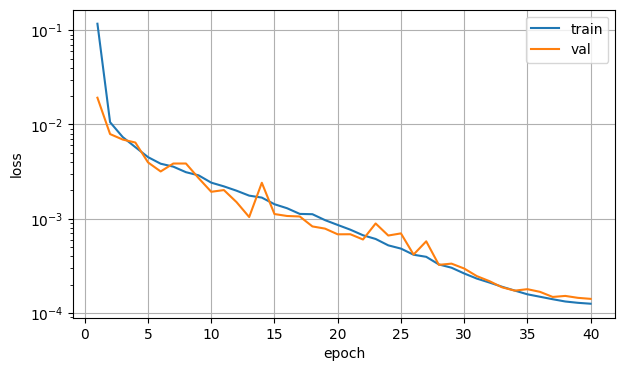

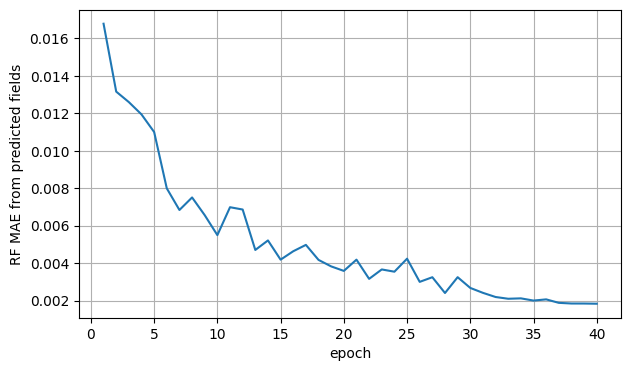

In [89]:

plt.figure(figsize=(7,4))
plt.plot(hist_df["epoch"], hist_df["train_loss"], label="train")
plt.plot(hist_df["epoch"], hist_df["loss"], label="val")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(hist_df["epoch"], hist_df["rf_mae_from_fields"])
plt.xlabel("epoch")
plt.ylabel("RF MAE from predicted fields")
plt.grid(True)
plt.show()



## 7. Visualize predicted pressure and water saturation fields

Because fields are weakly supervised, use these plots mainly as qualitative diagnostics.


In [ ]:

ckpt = torch.load(out_dir / "best_model.pt", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

@torch.no_grad()
def predict_one(sample_idx):
    inp, x_scaled, y_scaled, raw = dataset[sample_idx]
    inp_b = inp[None].to(device)
    x_scaled_b = x_scaled[None].to(device)
    x_raw_b = unscale_x(x_scaled_b)

    p_MPa, Sw, scalar_scaled = model(inp_b)
    y_pred = unscale_y(scalar_scaled).cpu().numpy()[0]
    y_true = unscale_y(y_scaled[None].to(device)).cpu().numpy()[0]
    rf_field = recovery_factor_from_fields(p_MPa, Sw, x_raw_b).cpu().numpy()[0]

    return {
        "p_MPa": p_MPa[0,0].cpu().numpy(),
        "Sw": Sw[0,0].cpu().numpy(),
        "y_pred": y_pred,
        "y_true": y_true,
        "rf_field": rf_field,
        "raw": raw,
    }

res = predict_one(0)

fig, ax = plt.subplots(1, 2, figsize=(11,4))
im0 = ax[0].imshow(res["p_MPa"], origin="lower")
ax[0].set_title("Predicted pressure, MPa")
plt.colorbar(im0, ax=ax[0])

im1 = ax[1].imshow(res["Sw"], origin="lower", vmin=0, vmax=1)
ax[1].set_title("Predicted water saturation")
plt.colorbar(im1, ax=ax[1])

plt.tight_layout()
plt.show()

print("RF true:", res["y_true"][target_index["final_recovery_factor"]])
print("RF predicted from field:", res["rf_field"])
print("RF predicted by scalar head:", res["y_pred"][target_index["final_recovery_factor"]])



## 8. Evaluate scalar predictions on validation set


In [ ]:

@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    rows = []

    for inp, x_scaled, y_scaled, raw in loader:
        inp = inp.to(device)
        x_scaled = x_scaled.to(device)
        y_scaled = y_scaled.to(device)

        p_MPa, Sw, scalar_scaled = model(inp)
        y_pred = unscale_y(scalar_scaled).cpu().numpy()
        y_true = unscale_y(y_scaled).cpu().numpy()

        x_raw = unscale_x(x_scaled)
        rf_field = recovery_factor_from_fields(p_MPa, Sw, x_raw).cpu().numpy()

        for i in range(y_pred.shape[0]):
            row = {}
            for j, c in enumerate(target_cols):
                row[f"true_{c}"] = y_true[i, j]
                row[f"pred_{c}"] = y_pred[i, j]
            row["pred_recovery_factor_from_field"] = rf_field[i]
            rows.append(row)

    return pd.DataFrame(rows)

pred_df = collect_predictions(model, val_loader)
pred_df.to_csv(out_dir / "validation_predictions.csv", index=False)
pred_df.head()


In [ ]:

def mae(a, b):
    return float(np.mean(np.abs(np.asarray(a) - np.asarray(b))))

metrics = []
for c in target_cols:
    metrics.append({
        "target": c,
        "MAE": mae(pred_df[f"true_{c}"], pred_df[f"pred_{c}"]),
        "true_mean": float(pred_df[f"true_{c}"].mean()),
    })

metrics_df = pd.DataFrame(metrics)
metrics_df


In [ ]:

for c in ["final_recovery_factor", "final_cum_oil_prod_m3", "final_water_inj_rate_m3_day"]:
    plt.figure(figsize=(5,5))
    plt.scatter(pred_df[f"true_{c}"], pred_df[f"pred_{c}"], s=12, alpha=0.7)
    lo = min(pred_df[f"true_{c}"].min(), pred_df[f"pred_{c}"].min())
    hi = max(pred_df[f"true_{c}"].max(), pred_df[f"pred_{c}"].max())
    plt.plot([lo, hi], [lo, hi])
    plt.xlabel(f"true {c}")
    plt.ylabel(f"pred {c}")
    plt.grid(True)
    plt.show()



## 9. Inference for new relative permeability parameters

This helper takes one row-like dictionary of physical parameters, changes relative permeability parameters, and predicts final scalar quantities plus pressure/saturation fields.


In [ ]:

@torch.no_grad()
def predict_for_parameters(base_row, updates=None):
    updates = updates or {}
    row = dict(base_row)
    row.update(updates)

    x = np.array([[row[c] for c in feature_cols]], dtype=np.float32)
    x_scaled = x_scaler.transform(x).astype(np.float32)

    x_scaled_t = torch.tensor(x_scaled, dtype=torch.float32)
    H, W = grid_cfg.model_Ny, grid_cfg.model_Nx

    yy, xx = torch.meshgrid(
        torch.linspace(0, 1, H),
        torch.linspace(0, 1, W),
        indexing="ij",
    )

    param_maps = x_scaled_t[0, :, None, None].expand(-1, H, W)
    inp = torch.cat([xx[None], yy[None], param_maps], dim=0)[None].to(device)

    p_MPa, Sw, scalar_scaled = model(inp)
    y_pred = unscale_y(scalar_scaled).cpu().numpy()[0]
    x_raw = unscale_x(torch.tensor(x_scaled, dtype=torch.float32).to(device))
    rf_field = recovery_factor_from_fields(p_MPa, Sw, x_raw).cpu().numpy()[0]

    out = {target_cols[i]: y_pred[i] for i in range(len(target_cols))}
    out["recovery_factor_from_predicted_field"] = rf_field

    return out, p_MPa[0,0].cpu().numpy(), Sw[0,0].cpu().numpy()

base_row = df.iloc[0].to_dict()

updates = {
    "krw0": 0.35,
    "kro0": 0.75,
    "nw_exp": 2.5,
    "no_exp": 2.0,
    "Swc": 0.18,
    "Sor": 0.22,
}

out, p_map, sw_map = predict_for_parameters(base_row, updates)
out


In [ ]:

fig, ax = plt.subplots(1, 2, figsize=(11,4))

im0 = ax[0].imshow(p_map, origin="lower")
ax[0].set_title("Pressure prediction, MPa")
plt.colorbar(im0, ax=ax[0])

im1 = ax[1].imshow(sw_map, origin="lower", vmin=0, vmax=1)
ax[1].set_title("Water saturation prediction")
plt.colorbar(im1, ax=ax[1])

plt.tight_layout()
plt.show()



## 10. Recommended improvement for a real U-Net PINN

For a proper U-Net-like PINN that predicts spatial distributions, modify the simulator to save snapshots:

```text
sim_id, time_years, p_grid[Nx,Ny], Sw_grid[Nx,Ny], parameters...
```

Then train with direct field losses:

\[
L_p = \|p_{\mathrm{pred}} - p_{\mathrm{sim}}\|^2
\]

\[
L_{S_w} = \|S_{w,\mathrm{pred}} - S_{w,\mathrm{sim}}\|^2
\]

plus physics residual losses. That version is significantly more identifiable than the weakly supervised version above.
